In [72]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math

In [73]:
dataset = pd.read_csv('data.csv')

In [74]:
N = 10000
d = 10

ads = []

times_selected = [0] * d
sum_of_rewards = [0] * d
total_reward = 0

In [75]:
for n in range(N):
  ad = 0
  max_upper_bound = 0

  for i in range(d):
    if(times_selected[i] > 0):
      average_reward = sum_of_rewards[i] / times_selected[i]
      confidence = math.sqrt(3/2 * math.log(n + 1)/times_selected[i])
      upper_bound = average_reward + confidence
    else:
      upper_bound = 1e400

    if(upper_bound > max_upper_bound):
      max_upper_bound = upper_bound
      ad = i

  ads.append(ad)
  times_selected[ad] += 1

  reward = dataset.values[n, ad]
  sum_of_rewards[ad] += reward

  total_reward += reward


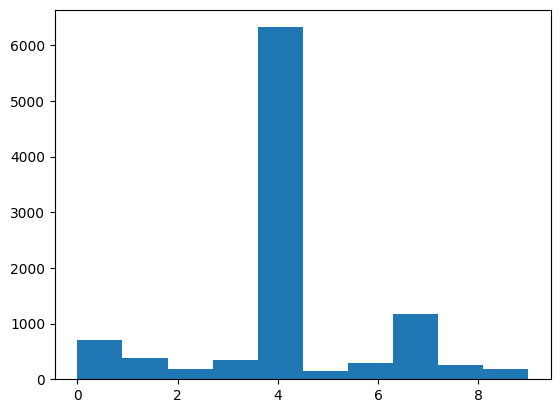

In [76]:
plt.hist(ads)
plt.show()